In [1]:
# Date 25/11/2025

In [2]:
# Dataset Split Code (80–10–10)

In [3]:
# The dataset split code divides your full image dataset into three parts:

# • 80% Training data – used to teach the model
# • 10% Validation data – used to tune the model during training
# • 10% Testing data – used to check final accuracy after training

In [4]:
import os
import shutil
import random


base_path = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1001-RiceLeaf\Data"

classes = [
    "Bacterial leaf blight",
    "Brown spot",
    "Leaf smut"
]

output_base = os.path.join(base_path, "Split_Data")
train_dir = os.path.join(output_base, "Train")
valid_dir = os.path.join(output_base, "Valid")
test_dir  = os.path.join(output_base, "Test")


for split in ["Train", "Valid", "Test"]:
    for cls in classes:
        os.makedirs(os.path.join(output_base, split, cls), exist_ok=True)


for cls in classes:
    cls_path = os.path.join(base_path, cls)
    images = os.listdir(cls_path)
    random.shuffle(images)

    n_total = len(images)
    n_train = int(0.8 * n_total)
    n_valid = int(0.1 * n_total)

    train_files = images[:n_train]
    valid_files = images[n_train:n_train + n_valid]
    test_files  = images[n_train + n_valid:]

    # Copy images
    for f in train_files:
        shutil.copy(os.path.join(cls_path, f), os.path.join(train_dir, cls))

    for f in valid_files:
        shutil.copy(os.path.join(cls_path, f), os.path.join(valid_dir, cls))

    for f in test_files:
        shutil.copy(os.path.join(cls_path, f), os.path.join(test_dir, cls))

print("Dataset successfully split into Train / Valid / Test!")


Dataset successfully split into Train / Valid / Test!


In [5]:
# Check the Split 

In [6]:
train_path = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1001-RiceLeaf\Data\Split_Data\Train"
print(os.listdir(train_path))


['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


In [7]:
#CNN model

In [8]:
# 1. ImageDataGenerator Code (Train / Validation / Test)

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1001-RiceLeaf\Data\Split_Data\Train"
valid_dir = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1001-RiceLeaf\Data\Split_Data\Valid"
test_dir  = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1001-RiceLeaf\Data\Split_Data\Test"

# Training with augmentation
train_gen = ImageDataGenerator(
    rescale=1/255.0,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True
)

# Validation and test (no augmentation)
val_test_gen = ImageDataGenerator(rescale=1/255.0)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

valid_data = val_test_gen.flow_from_directory(
    valid_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_data = val_test_gen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 119 images belonging to 3 classes.
Found 52 images belonging to 3 classes.
Found 60 images belonging to 3 classes.


In [10]:
# 2.  Custom  CNN Model 

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')  # 3 classes
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 54, 54, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 26, 26, 128)      0

In [12]:
# 3. Train the Model

In [13]:
history = model.fit(
    train_data,
    epochs=50,
    validation_data=valid_data
)


Epoch 1/50
4/4 [==============================] - 8s 2s/step - loss: 5.2388 - accuracy: 0.3529 - val_loss: 1.9929 - val_accuracy: 0.3846
Epoch 2/50
4/4 [==============================] - 5s 1s/step - loss: 1.3695 - accuracy: 0.3277 - val_loss: 1.1244 - val_accuracy: 0.2885
Epoch 3/50
4/4 [==============================] - 5s 1s/step - loss: 1.1170 - accuracy: 0.3361 - val_loss: 1.0908 - val_accuracy: 0.2885
Epoch 4/50
4/4 [==============================] - 5s 1s/step - loss: 1.0941 - accuracy: 0.3782 - val_loss: 1.0740 - val_accuracy: 0.4231
Epoch 5/50
4/4 [==============================] - 5s 1s/step - loss: 1.0846 - accuracy: 0.3445 - val_loss: 1.0117 - val_accuracy: 0.5385
Epoch 6/50
4/4 [==============================] - 5s 1s/step - loss: 1.0627 - accuracy: 0.3950 - val_loss: 1.0089 - val_accuracy: 0.3846
Epoch 7/50
4/4 [==============================] - 5s 1s/step - loss: 1.0168 - accuracy: 0.4454 - val_loss: 0.9827 - val_accuracy: 0.5577
Epoch 8/50
4/4 [=========================

In [14]:
# 4. Evaluate on Test Set

In [15]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)


2/2 [==============================] - 1s 690ms/step - loss: 0.3664 - accuracy: 0.8500
Test Accuracy: 0.8500000238418579


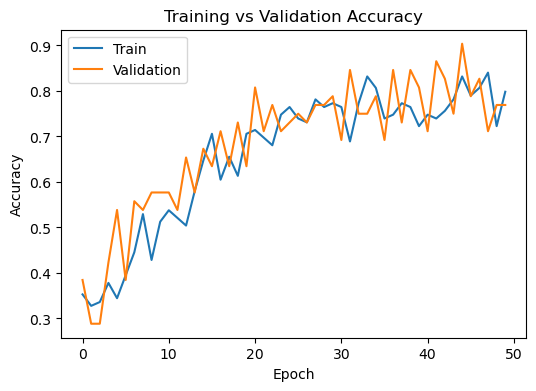

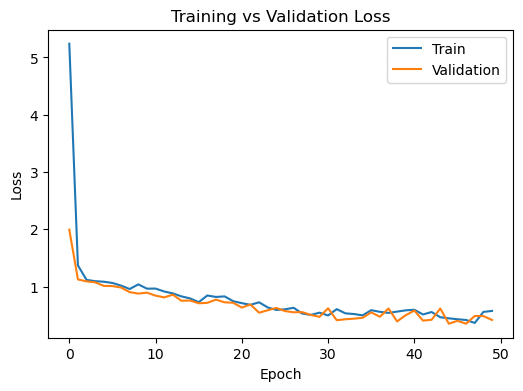

In [16]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss graph
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()


2/2 [==============================] - 1s 475ms/step


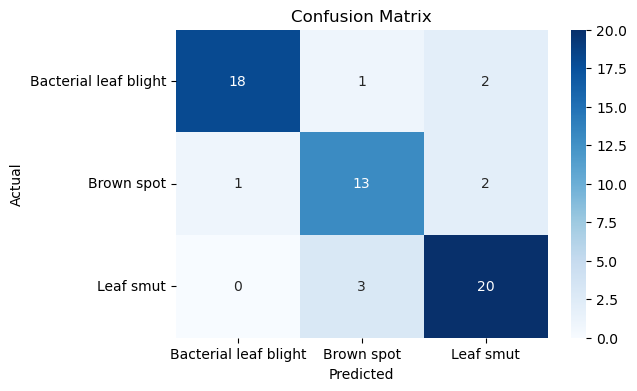

                       precision    recall  f1-score   support

Bacterial leaf blight       0.95      0.86      0.90        21
           Brown spot       0.76      0.81      0.79        16
            Leaf smut       0.83      0.87      0.85        23

             accuracy                           0.85        60
            macro avg       0.85      0.85      0.85        60
         weighted avg       0.85      0.85      0.85        60



In [17]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Get true labels
true_labels = test_data.classes

# Predict
pred_probs = model.predict(test_data)
pred_labels = np.argmax(pred_probs, axis=1)

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Class names
class_names = list(test_data.class_indices.keys())

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print(classification_report(true_labels, pred_labels, target_names=class_names))


In [18]:
## Tansfer leaning (VGG16)

In [19]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

vgg = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze VGG16 base
for layer in vgg.layers:
    layer.trainable = False

model = Sequential([
    vgg,
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(3, activation='softmax')  # 3 classes
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 flatten_1 (Flatten)         (None, 25088)             0         
                                                                 
 dense_2 (Dense)             (None, 512)               12845568  
                                                                 
 dropout_1 (Dropout)         (None, 512)               0         
                                                                 
 dense_3 (Dense)             (None, 3)                 1539      
                                                                 
Total params: 27,561,795
Trainable params: 12,847,107
Non-trainable params: 14,714,688
_________________________________________________________________


In [20]:
history = model.fit(
    train_data,
    epochs=50,
    validation_data=valid_data
)


Epoch 1/50
4/4 [==============================] - 9s 3s/step - loss: 1.5439 - accuracy: 0.2521 - val_loss: 1.2583 - val_accuracy: 0.5192
Epoch 2/50
4/4 [==============================] - 8s 2s/step - loss: 1.3473 - accuracy: 0.4286 - val_loss: 0.7659 - val_accuracy: 0.7308
Epoch 3/50
4/4 [==============================] - 8s 2s/step - loss: 1.0067 - accuracy: 0.4790 - val_loss: 0.6818 - val_accuracy: 0.7885
Epoch 4/50
4/4 [==============================] - 8s 2s/step - loss: 0.8006 - accuracy: 0.6975 - val_loss: 0.6047 - val_accuracy: 0.7692
Epoch 5/50
4/4 [==============================] - 8s 2s/step - loss: 0.7783 - accuracy: 0.6471 - val_loss: 0.5209 - val_accuracy: 0.8462
Epoch 6/50
4/4 [==============================] - 8s 2s/step - loss: 0.7174 - accuracy: 0.6723 - val_loss: 0.4904 - val_accuracy: 0.8462
Epoch 7/50
4/4 [==============================] - 8s 2s/step - loss: 0.5965 - accuracy: 0.7899 - val_loss: 0.4304 - val_accuracy: 0.8269
Epoch 8/50
4/4 [=========================

In [21]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)


2/2 [==============================] - 3s 1s/step - loss: 0.0764 - accuracy: 1.0000
Test Accuracy: 1.0


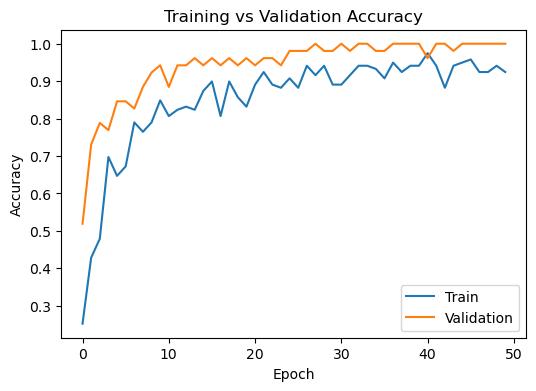

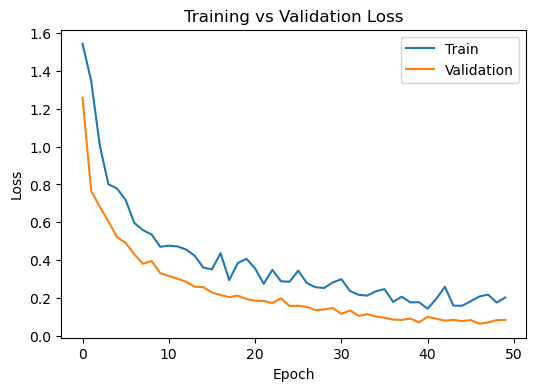

In [22]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss graph
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()


2/2 [==============================] - 3s 1s/step


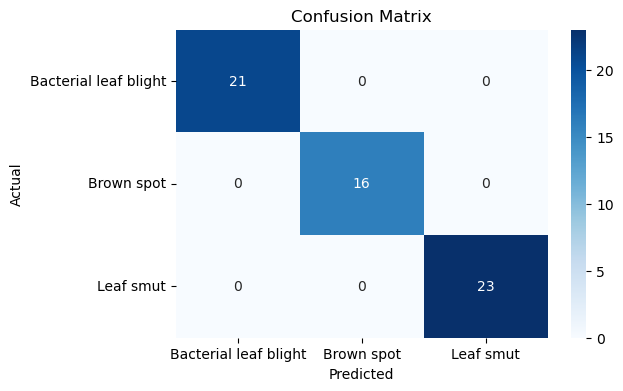

                       precision    recall  f1-score   support

Bacterial leaf blight       1.00      1.00      1.00        21
           Brown spot       1.00      1.00      1.00        16
            Leaf smut       1.00      1.00      1.00        23

             accuracy                           1.00        60
            macro avg       1.00      1.00      1.00        60
         weighted avg       1.00      1.00      1.00        60



In [23]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Get true labels
true_labels = test_data.classes

# Predict
pred_probs = model.predict(test_data)
pred_labels = np.argmax(pred_probs, axis=1)

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Class names
class_names = list(test_data.class_indices.keys())

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print(classification_report(true_labels, pred_labels, target_names=class_names))


In [24]:
# EfficientNetB0

In [25]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import os


In [33]:
# 2. Image Data Generators

In [35]:
# Dataset paths
train_path = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1001-RiceLeaf\Data\Split_Data\Train"
valid_path = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1001-RiceLeaf\Data\Split_Data\Valid"
test_path  = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1001-RiceLeaf\Data\Split_Data\Test"

# Image size and batch size
img_size = (224, 224)
batch_size = 32

# Data generators
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen  = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    train_path, target_size=img_size, batch_size=batch_size, class_mode='categorical'
)

valid_gen = valid_datagen.flow_from_directory(
    valid_path, target_size=img_size, batch_size=batch_size, class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    test_path, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)


Found 119 images belonging to 3 classes.
Found 52 images belonging to 3 classes.
Found 60 images belonging to 3 classes.


In [42]:
# Compile Model 

In [43]:
model.compile(
    optimizer=Adam(1e-5),   # fine-tuning requires small LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [44]:
# Training Code

In [45]:
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=50,
    steps_per_epoch=train_gen.samples // batch_size,
    validation_steps=valid_gen.samples // batch_size
)


Epoch 1/50
3/3 [==============================] - 7s 3s/step - loss: 6.8689 - accuracy: 0.7586 - val_loss: 6.8680 - val_accuracy: 0.7812
Epoch 2/50
3/3 [==============================] - 6s 2s/step - loss: 6.5691 - accuracy: 0.8046 - val_loss: 5.9781 - val_accuracy: 0.8750
Epoch 3/50
3/3 [==============================] - 6s 2s/step - loss: 4.4837 - accuracy: 0.8046 - val_loss: 5.0693 - val_accuracy: 0.8750
Epoch 4/50
3/3 [==============================] - 6s 2s/step - loss: 3.8155 - accuracy: 0.8276 - val_loss: 3.1221 - val_accuracy: 0.8750
Epoch 5/50
3/3 [==============================] - 6s 2s/step - loss: 6.5352 - accuracy: 0.7816 - val_loss: 2.8576 - val_accuracy: 0.8750
Epoch 6/50
3/3 [==============================] - 7s 2s/step - loss: 5.2058 - accuracy: 0.8542 - val_loss: 4.1880 - val_accuracy: 0.8750
Epoch 7/50
3/3 [==============================] - 6s 2s/step - loss: 5.9343 - accuracy: 0.8229 - val_loss: 2.9541 - val_accuracy: 0.9062
Epoch 8/50
3/3 [=========================

In [46]:
# Accuracy & Loss Plot Code

In [47]:
test_loss, test_acc = model.evaluate(test_gen)
print("Final Test Accuracy:", test_acc)


2/2 [==============================] - 3s 1s/step - loss: 0.2739 - accuracy: 0.9500
Final Test Accuracy: 0.949999988079071


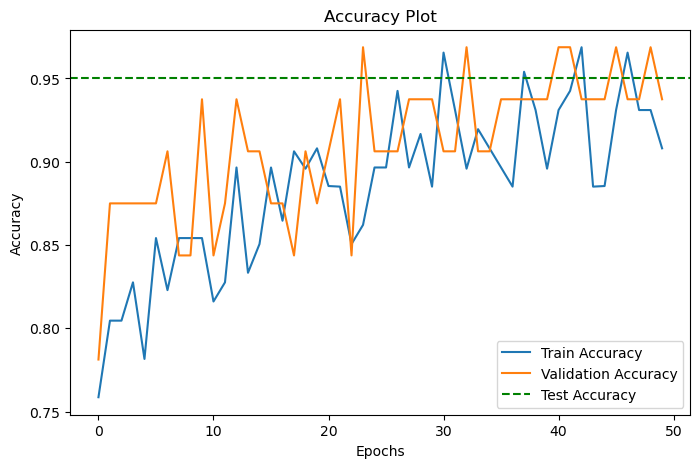

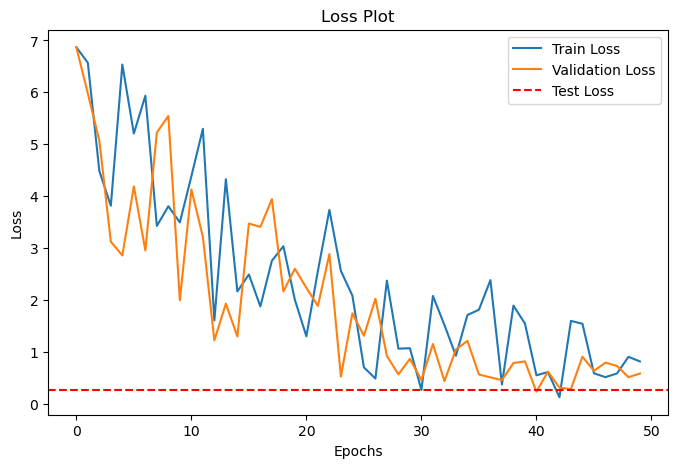

In [48]:


# Accuracy plot
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.axhline(test_acc, color='green', linestyle='--', label='Test Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Plot")
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.axhline(test_loss, color='red', linestyle='--', label='Test Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Plot")
plt.legend()
plt.show()


In [49]:
#  DenseNet121

In [51]:
# DenseNet121 fine-tuned model 

In [52]:
# 1. Imports

In [53]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import os


In [54]:
# 2. Data Generators (DenseNet requires preprocess_input)

In [55]:
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen  = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    train_path, target_size=img_size, batch_size=batch_size, class_mode='categorical'
)

valid_gen = valid_datagen.flow_from_directory(
    valid_path, target_size=img_size, batch_size=batch_size, class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    test_path, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)


Found 119 images belonging to 3 classes.
Found 52 images belonging to 3 classes.
Found 60 images belonging to 3 classes.


In [56]:
#  Compile 

In [57]:
model.compile(
    optimizer=Adam(1e-5),    # IMPORTANT
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [58]:
# Train Model

In [59]:
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=50,
    steps_per_epoch=train_gen.samples // batch_size,
    validation_steps=valid_gen.samples // batch_size
)


Epoch 1/50
3/3 [==============================] - 7s 3s/step - loss: 0.9121 - accuracy: 0.6322 - val_loss: 0.2544 - val_accuracy: 0.8750
Epoch 2/50
3/3 [==============================] - 6s 2s/step - loss: 0.4161 - accuracy: 0.7931 - val_loss: 0.1499 - val_accuracy: 1.0000
Epoch 3/50
3/3 [==============================] - 6s 2s/step - loss: 0.3411 - accuracy: 0.8621 - val_loss: 0.2165 - val_accuracy: 0.9375
Epoch 4/50
3/3 [==============================] - 6s 2s/step - loss: 0.3220 - accuracy: 0.8438 - val_loss: 0.2071 - val_accuracy: 0.8750
Epoch 5/50
3/3 [==============================] - 6s 2s/step - loss: 0.1765 - accuracy: 0.9195 - val_loss: 0.0845 - val_accuracy: 1.0000
Epoch 6/50
3/3 [==============================] - 6s 2s/step - loss: 0.2233 - accuracy: 0.9080 - val_loss: 0.1101 - val_accuracy: 0.9688
Epoch 7/50
3/3 [==============================] - 6s 2s/step - loss: 0.2254 - accuracy: 0.9062 - val_loss: 0.1640 - val_accuracy: 0.9688
Epoch 8/50
3/3 [=========================

In [60]:
#  Evaluate Model

In [61]:
test_loss, test_acc = model.evaluate(test_gen)
print("Final DenseNet121 Test Accuracy:", test_acc)


2/2 [==============================] - 3s 1s/step - loss: 0.0438 - accuracy: 0.9833
Final DenseNet121 Test Accuracy: 0.9833333492279053


In [62]:
#  Accuracy & Loss Graph

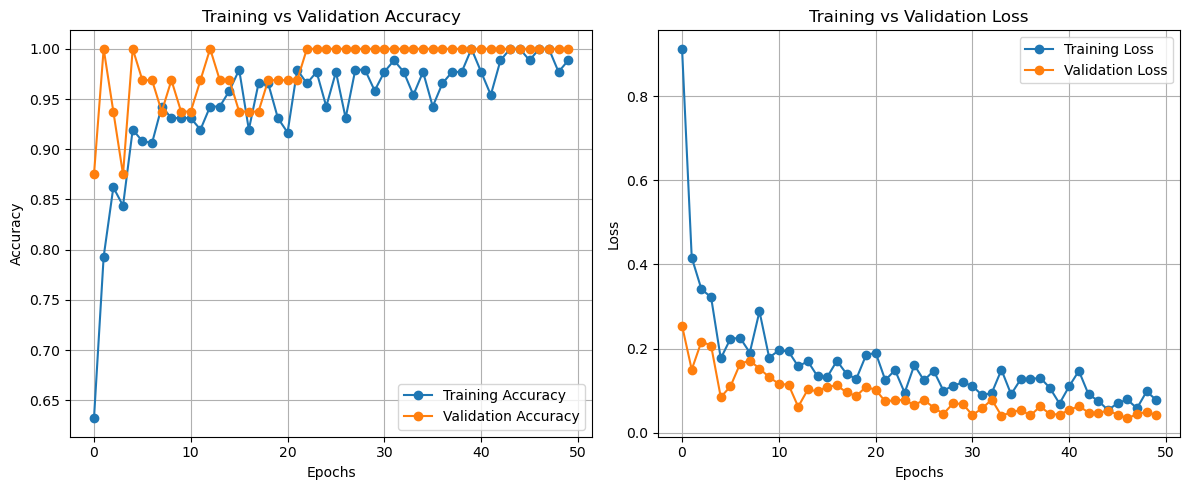

In [63]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [64]:
# Confusion Matrix & Classification Report

2/2 [==============================] - 3s 1s/step


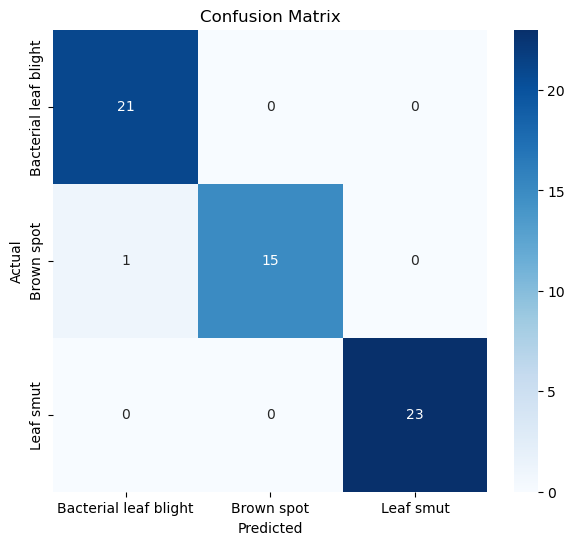

Classification Report:
                       precision    recall  f1-score   support

Bacterial leaf blight       0.95      1.00      0.98        21
           Brown spot       1.00      0.94      0.97        16
            Leaf smut       1.00      1.00      1.00        23

             accuracy                           0.98        60
            macro avg       0.98      0.98      0.98        60
         weighted avg       0.98      0.98      0.98        60



In [65]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns

# Predict on test data
pred = model.predict(test_gen)
pred_classes = np.argmax(pred, axis=1)

true_classes = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(true_classes, pred_classes, target_names=class_labels))


In [66]:
test_loss, test_acc = model.evaluate(test_gen)
print("Final Test Accuracy:", round(test_acc*100, 2), "%")
print("Final Test Loss:", round(test_loss, 4))

print("\nClass distribution in test set:")
for cls, idx in test_gen.class_indices.items():
    print(f"{cls}: {(true_classes==idx).sum()} images")


2/2 [==============================] - 4s 1s/step - loss: 0.0438 - accuracy: 0.9833
Final Test Accuracy: 98.33 %
Final Test Loss: 0.0438

Class distribution in test set:
Bacterial leaf blight: 21 images
Brown spot: 16 images
Leaf smut: 23 images


In [67]:
# InceptionV3

In [86]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import os


In [87]:
#  Paths & Parameters

In [95]:


img_size = (299, 299)  # InceptionV3 requires 299x299
batch_size = 32


In [96]:
#  Data Generators

In [102]:

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen  = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    train_path, target_size=img_size, batch_size=batch_size, class_mode='categorical'
)

valid_gen = valid_datagen.flow_from_directory(
    valid_path, target_size=img_size, batch_size=batch_size, class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    test_path, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)


Found 119 images belonging to 3 classes.
Found 52 images belonging to 3 classes.
Found 60 images belonging to 3 classes.


In [98]:
#  Compile Model

In [103]:


base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299,299,3))
base_model.trainable = False  # freeze base

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(train_gen.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 299, 299, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_97 (Conv2D)             (None, 149, 149, 32  864         ['input_4[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization_94 (BatchN  (None, 149, 149, 32  96         ['conv2d_97[0][0]']              
 ormalization)                  )                                                             

In [104]:
# Train Model

In [105]:
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=50,
    steps_per_epoch=len(train_gen),
    validation_steps=len(valid_gen)
)


Epoch 1/50
4/4 [==============================] - 13s 3s/step - loss: 1.1691 - accuracy: 0.3697 - val_loss: 0.9532 - val_accuracy: 0.5962
Epoch 2/50
4/4 [==============================] - 7s 2s/step - loss: 1.0590 - accuracy: 0.4286 - val_loss: 0.8777 - val_accuracy: 0.6538
Epoch 3/50
4/4 [==============================] - 8s 2s/step - loss: 0.8686 - accuracy: 0.6555 - val_loss: 0.7448 - val_accuracy: 0.8269
Epoch 4/50
4/4 [==============================] - 7s 2s/step - loss: 0.7813 - accuracy: 0.7143 - val_loss: 0.6735 - val_accuracy: 0.8462
Epoch 5/50
4/4 [==============================] - 7s 2s/step - loss: 0.6726 - accuracy: 0.7983 - val_loss: 0.6277 - val_accuracy: 0.8654
Epoch 6/50
4/4 [==============================] - 7s 2s/step - loss: 0.6578 - accuracy: 0.7731 - val_loss: 0.5697 - val_accuracy: 0.8846
Epoch 7/50
4/4 [==============================] - 7s 2s/step - loss: 0.6089 - accuracy: 0.7983 - val_loss: 0.5405 - val_accuracy: 0.8846
Epoch 8/50
4/4 [========================

In [106]:
#  Evaluate on Test Set

In [107]:
test_loss, test_acc = model.evaluate(test_gen)
print("Final Test Accuracy:", round(test_acc*100, 2), "%")
print("Final Test Loss:", round(test_loss, 4))


2/2 [==============================] - 2s 778ms/step - loss: 0.0983 - accuracy: 0.9667
Final Test Accuracy: 96.67 %
Final Test Loss: 0.0983


In [108]:
#  Plot Accuracy & Loss

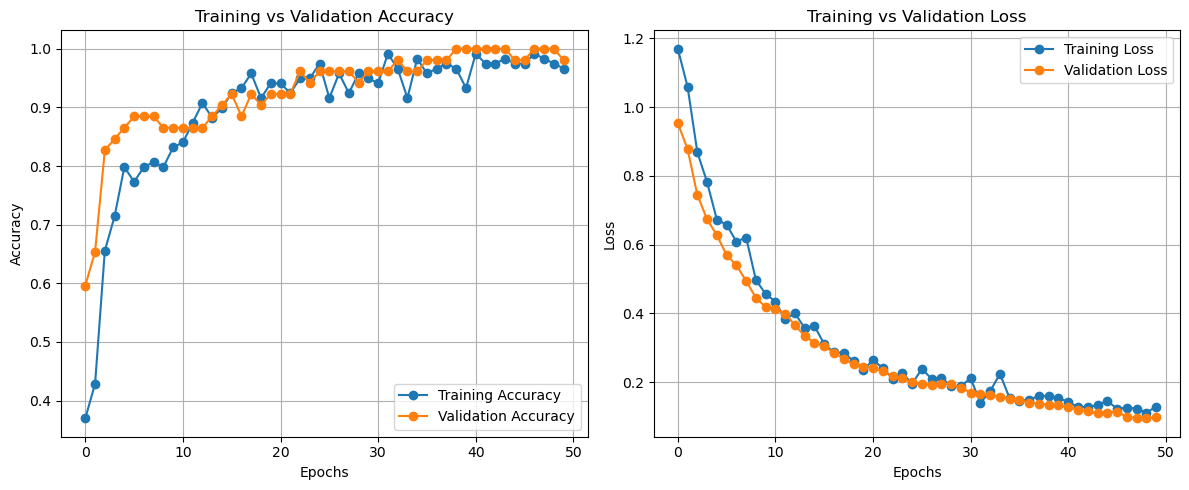

In [109]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [110]:
# Confusion Matrix & Classification Report

2/2 [==============================] - 3s 766ms/step


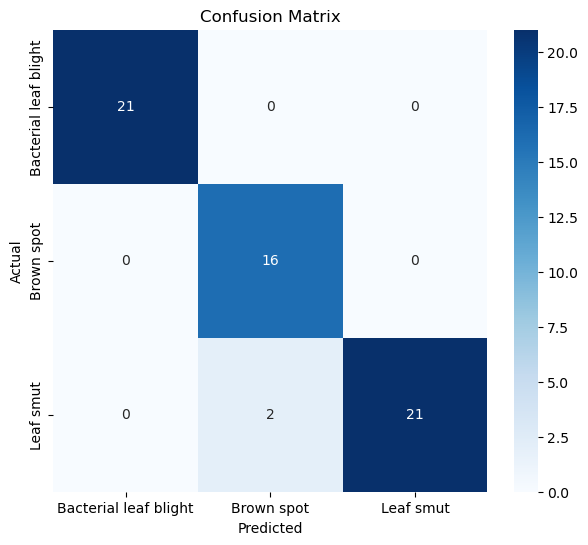

Classification Report:
                       precision    recall  f1-score   support

Bacterial leaf blight       1.00      1.00      1.00        21
           Brown spot       0.89      1.00      0.94        16
            Leaf smut       1.00      0.91      0.95        23

             accuracy                           0.97        60
            macro avg       0.96      0.97      0.97        60
         weighted avg       0.97      0.97      0.97        60



In [111]:
pred = model.predict(test_gen)
pred_classes = np.argmax(pred, axis=1)
true_classes = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(true_classes, pred_classes, target_names=class_labels))


In [112]:
# Date : 27/11/2025

In [113]:
# Vgg19 

In [114]:
# 1 Imports

In [115]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [116]:
# 2 paths

In [117]:
train_dir = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1001-RiceLeaf\Data\Split_Data\Train"
valid_dir = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1001-RiceLeaf\Data\Split_Data\Valid"
test_dir  = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1001-RiceLeaf\Data\Split_Data\Test"

img_size = (224, 224)
batch = 32


In [118]:
# 3 Data Augmentation

In [119]:
train_gen = ImageDataGenerator(
    rescale=1/255.0,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1/255.0)
test_gen = ImageDataGenerator(rescale=1/255.0)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    valid_dir,
    target_size=img_size,
    batch_size=batch,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch,
    class_mode='categorical',
    shuffle=False
)


Found 119 images belonging to 3 classes.
Found 52 images belonging to 3 classes.
Found 60 images belonging to 3 classes.


In [120]:
# Function to count images per class
def count_images_per_class(generator):
    class_counts = {}
    for class_name, class_index in generator.class_indices.items():
        class_counts[class_name] = sum(generator.labels == class_index)
    return class_counts

# Training set
train_counts = count_images_per_class(train_data)
print("Training set:")
for cls, count in train_counts.items():
    print(f"{cls}: {count} images")

# Validation set
val_counts = count_images_per_class(val_data)
print("\nValidation set:")
for cls, count in val_counts.items():
    print(f"{cls}: {count} images")

# Test set
test_counts = count_images_per_class(test_data)
print("\nTest set:")
for cls, count in test_counts.items():
    print(f"{cls}: {count} images")


Training set:
Bacterial leaf blight: 40 images
Brown spot: 40 images
Leaf smut: 39 images

Validation set:
Bacterial leaf blight: 20 images
Brown spot: 18 images
Leaf smut: 14 images

Test set:
Bacterial leaf blight: 21 images
Brown spot: 16 images
Leaf smut: 23 images


In [121]:
# 4 Build VGG19 Model

In [122]:
base = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base.layers:
    layer.trainable = False

x = Flatten()(base.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base.input, outputs=output)
model.summary()


Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0   

In [123]:
# 5 Compile Model

In [124]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [125]:
# 6 Callbacks

In [126]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.4,
    patience=3,
    min_lr=1e-7
)


In [127]:
# 7 Train Model

In [128]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/50
4/4 [==============================] - 11s 3s/step - loss: 7.8976 - accuracy: 0.3025 - val_loss: 1.4560 - val_accuracy: 0.6731 - lr: 0.0010
Epoch 2/50
4/4 [==============================] - 10s 2s/step - loss: 3.8911 - accuracy: 0.3361 - val_loss: 2.7876 - val_accuracy: 0.5192 - lr: 0.0010
Epoch 3/50
4/4 [==============================] - 10s 3s/step - loss: 2.5159 - accuracy: 0.4706 - val_loss: 0.9788 - val_accuracy: 0.5000 - lr: 0.0010
Epoch 4/50
4/4 [==============================] - 10s 3s/step - loss: 1.5446 - accuracy: 0.4538 - val_loss: 0.8240 - val_accuracy: 0.6346 - lr: 0.0010
Epoch 5/50
4/4 [==============================] - 10s 3s/step - loss: 1.2151 - accuracy: 0.5798 - val_loss: 0.6943 - val_accuracy: 0.6923 - lr: 0.0010
Epoch 6/50
4/4 [==============================] - 10s 2s/step - loss: 0.8444 - accuracy: 0.6218 - val_loss: 0.6335 - val_accuracy: 0.8077 - lr: 0.0010
Epoch 7/50
4/4 [==============================] - 10s 3s/step - loss: 0.7522 - accuracy: 0.663

In [133]:
# 8 Test Accuracy and Loss

In [135]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)



2/2 [==============================] - 3s 1s/step - loss: 0.1584 - accuracy: 0.9333
Test Accuracy: 0.9333333373069763


In [136]:
# 9 Training and Validation Plots

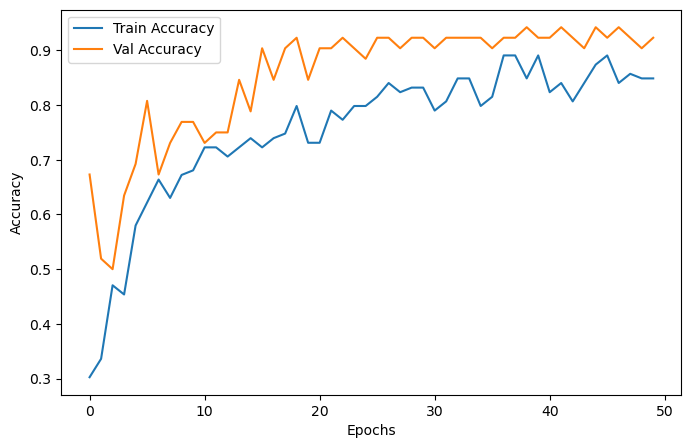

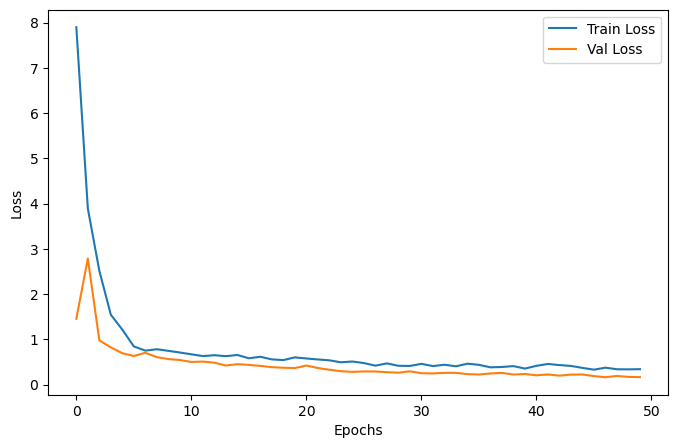

In [137]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [138]:
# 10 Confusion Matrix

2/2 [==============================] - 4s 1s/step


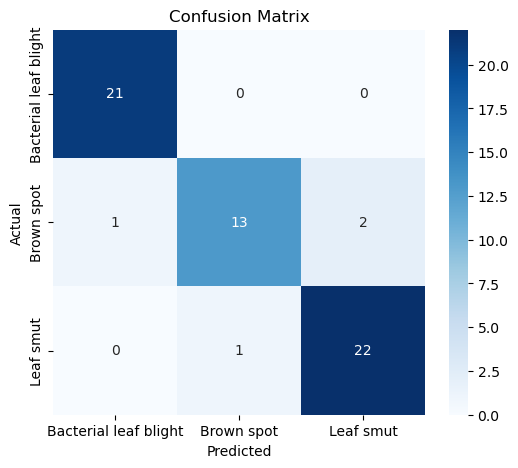

                       precision    recall  f1-score   support

Bacterial leaf blight       0.95      1.00      0.98        21
           Brown spot       0.93      0.81      0.87        16
            Leaf smut       0.92      0.96      0.94        23

             accuracy                           0.93        60
            macro avg       0.93      0.92      0.93        60
         weighted avg       0.93      0.93      0.93        60



In [139]:
pred = model.predict(test_data)
pred_classes = np.argmax(pred, axis=1)
true_classes = test_data.classes

cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(test_data.class_indices.keys()),
            yticklabels=list(test_data.class_indices.keys()))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

labels = list(test_data.class_indices.keys())
print(classification_report(true_classes, pred_classes, target_names=labels))



In [140]:
# Date 28/11/2025

In [141]:
# ResNet50

In [142]:
# Imports

In [143]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [144]:
# Paths

In [145]:
train_dir = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1001-RiceLeaf\Data\Split_Data\Train"
valid_dir = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1001-RiceLeaf\Data\Split_Data\Valid"
test_dir  = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1001-RiceLeaf\Data\Split_Data\Test"


In [146]:
#  Data argumentation

In [147]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
).flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

valid_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    valid_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 119 images belonging to 3 classes.
Found 52 images belonging to 3 classes.
Found 60 images belonging to 3 classes.


In [148]:
#  Model

In [149]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(train_gen.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_6 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_6[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                            

In [151]:
# Train model 

In [152]:
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=50
)


Epoch 1/50
4/4 [==============================] - 10s 2s/step - loss: 1.1711 - accuracy: 0.3950 - val_loss: 1.3525 - val_accuracy: 0.2692
Epoch 2/50
4/4 [==============================] - 7s 2s/step - loss: 1.1904 - accuracy: 0.3445 - val_loss: 1.0858 - val_accuracy: 0.3846
Epoch 3/50
4/4 [==============================] - 7s 2s/step - loss: 1.1499 - accuracy: 0.3361 - val_loss: 1.0845 - val_accuracy: 0.3846
Epoch 4/50
4/4 [==============================] - 7s 2s/step - loss: 1.1044 - accuracy: 0.3613 - val_loss: 1.1451 - val_accuracy: 0.2692
Epoch 5/50
4/4 [==============================] - 7s 2s/step - loss: 1.1367 - accuracy: 0.3782 - val_loss: 1.1408 - val_accuracy: 0.3462
Epoch 6/50
4/4 [==============================] - 7s 2s/step - loss: 1.1277 - accuracy: 0.2521 - val_loss: 1.1055 - val_accuracy: 0.3846
Epoch 7/50
4/4 [==============================] - 7s 2s/step - loss: 1.1137 - accuracy: 0.3361 - val_loss: 1.0726 - val_accuracy: 0.4038
Epoch 8/50
4/4 [========================

In [153]:
test_loss, test_acc = model.evaluate(test_gen)
print("Test accuracy:", test_acc)


2/2 [==============================] - 2s 872ms/step - loss: 1.0130 - accuracy: 0.6167
Test accuracy: 0.6166666746139526


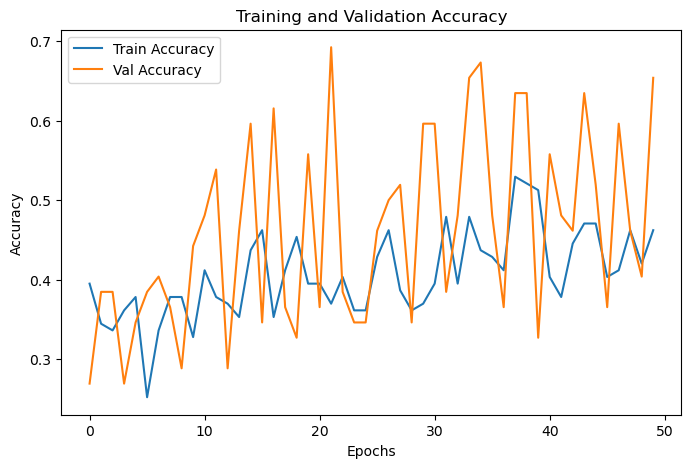

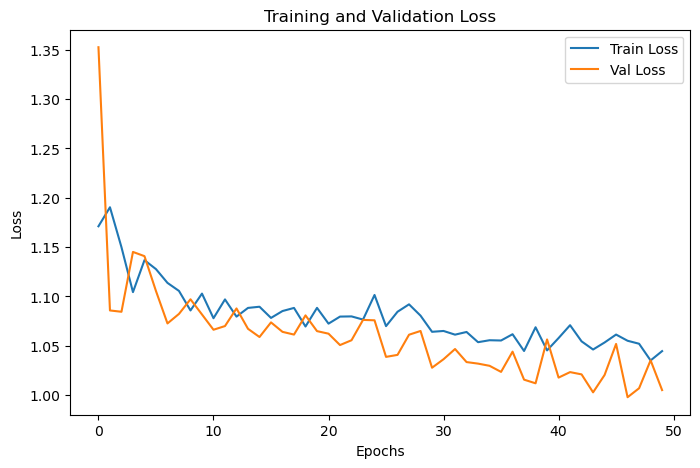

In [154]:

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()


2/2 [==============================] - 3s 858ms/step


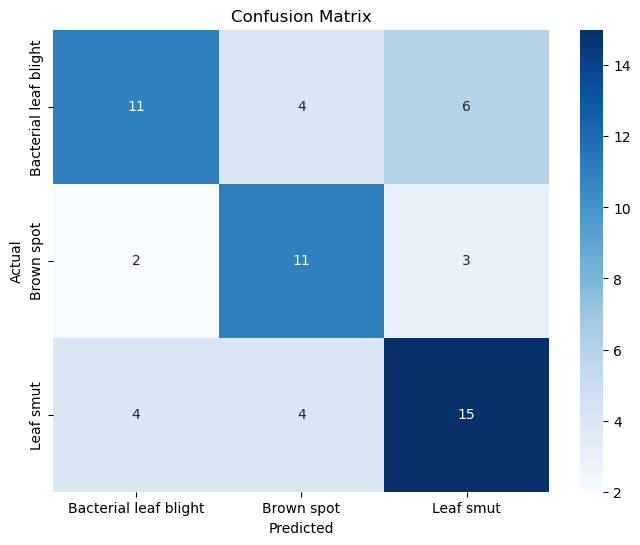

In [155]:
# Predictions
pred_probs = model.predict(test_gen)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [156]:
cr = classification_report(true_classes, pred_classes, target_names=class_labels)
print(cr)


                       precision    recall  f1-score   support

Bacterial leaf blight       0.65      0.52      0.58        21
           Brown spot       0.58      0.69      0.63        16
            Leaf smut       0.62      0.65      0.64        23

             accuracy                           0.62        60
            macro avg       0.62      0.62      0.62        60
         weighted avg       0.62      0.62      0.61        60



In [ ]:
# Xception

In [157]:


train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
).flow_from_directory(
    train_dir,
    target_size=(299, 299),
    batch_size=32,
    class_mode='categorical'
)

valid_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    valid_dir,
    target_size=(299, 299),
    batch_size=32,
    class_mode='categorical'
)

test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=(299, 299),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 119 images belonging to 3 classes.
Found 52 images belonging to 3 classes.
Found 60 images belonging to 3 classes.


In [158]:
#  Xception model

In [159]:
from tensorflow.keras.applications import Xception


In [160]:
base = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(299, 299, 3)
)

base.trainable = False

x = GlobalAveragePooling2D()(base.output)
x = Dense(256, activation='relu')(x)
out = Dense(train_gen.num_classes, activation='softmax')(x)

model = Model(base.input, out)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_7 (InputLayer)           [(None, 299, 299, 3  0           []                               
                                )]                                                                
                                                                                                  
 block1_conv1 (Conv2D)          (None, 149, 149, 32  864         ['input_7[0][0]']                
                                )                                                                 
                                                                                                  
 block1_conv1_bn (BatchNormaliz  (None, 149, 149, 32  128        ['block1_conv1[0][0]']           
 ation)                         )                                                           

In [161]:
# Train model

In [162]:


history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=50,
)


Epoch 1/50
4/4 [==============================] - 13s 3s/step - loss: 0.9223 - accuracy: 0.4874 - val_loss: 0.5544 - val_accuracy: 0.8269
Epoch 2/50
4/4 [==============================] - 11s 3s/step - loss: 0.5090 - accuracy: 0.8319 - val_loss: 0.3893 - val_accuracy: 0.9423
Epoch 3/50
4/4 [==============================] - 13s 3s/step - loss: 0.3319 - accuracy: 0.9076 - val_loss: 0.3063 - val_accuracy: 0.9231
Epoch 4/50
4/4 [==============================] - 11s 3s/step - loss: 0.2934 - accuracy: 0.8824 - val_loss: 0.2019 - val_accuracy: 0.9231
Epoch 5/50
4/4 [==============================] - 11s 3s/step - loss: 0.2185 - accuracy: 0.9160 - val_loss: 0.2554 - val_accuracy: 0.8846
Epoch 6/50
4/4 [==============================] - 11s 3s/step - loss: 0.1616 - accuracy: 0.9496 - val_loss: 0.1289 - val_accuracy: 0.9615
Epoch 7/50
4/4 [==============================] - 11s 3s/step - loss: 0.0853 - accuracy: 1.0000 - val_loss: 0.0998 - val_accuracy: 0.9615
Epoch 8/50
4/4 [==================

In [163]:
# Test evaluation

In [164]:
test_loss, test_acc = model.evaluate(test_gen)
print("Test Accuracy:", test_acc)


2/2 [==============================] - 3s 1s/step - loss: 0.0072 - accuracy: 1.0000
Test Accuracy: 1.0


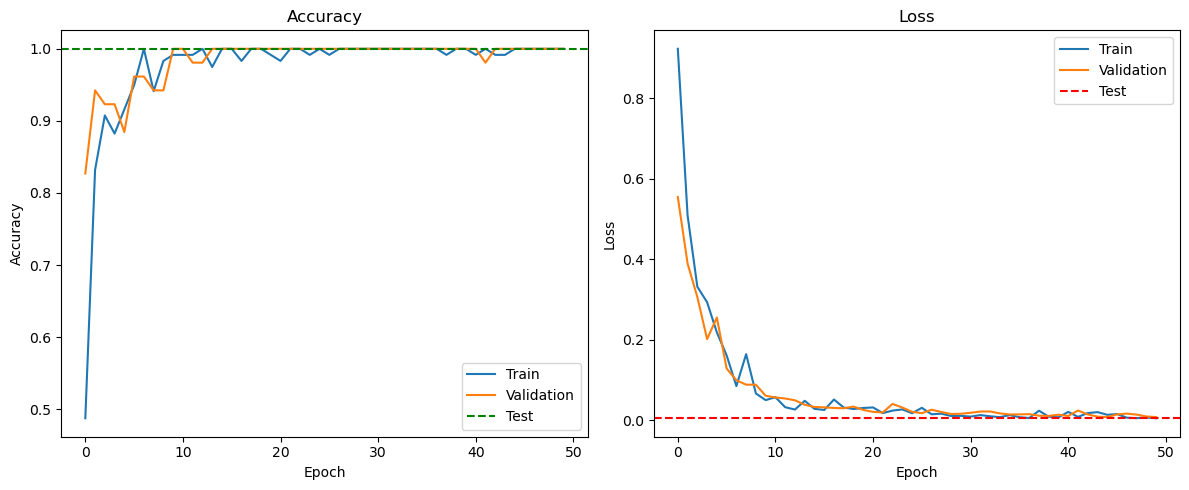

In [165]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.axhline(test_acc, color='green', linestyle='--', label='Test')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.axhline(test_loss, color='red', linestyle='--', label='Test')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


In [166]:
pred = model.predict(test_gen)
pred_classes = np.argmax(pred, axis=1)
true = test_gen.classes

cm = confusion_matrix(true, pred_classes)
print("Confusion Matrix:\n", cm)

labels = list(test_gen.class_indices.keys())
print("\nClassification Report:")
print(classification_report(true, pred_classes, target_names=labels))


2/2 [==============================] - 4s 1s/step
Confusion Matrix:
 [[21  0  0]
 [ 0 16  0]
 [ 0  0 23]]

Classification Report:
                       precision    recall  f1-score   support

Bacterial leaf blight       1.00      1.00      1.00        21
           Brown spot       1.00      1.00      1.00        16
            Leaf smut       1.00      1.00      1.00        23

             accuracy                           1.00        60
            macro avg       1.00      1.00      1.00        60
         weighted avg       1.00      1.00      1.00        60



In [1]:
# ## paraameter tuning 

In [2]:
"Both the VGG16 and Xception architectures produced an accuracy score of 1.0; however, this unusually high performance likely indicates overfitting or data leakage rather than genuine model effectiveness."

'Both the VGG16 and Xception architectures produced an accuracy score of 1.0; however, this unusually high performance likely indicates overfitting or data leakage rather than genuine model effectiveness.'

In [32]:
## VGG 16

In [3]:
# After Model Tuning 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import tensorflow as tf
import cv2
import os
import shutil
import random
from collections import Counter


In [2]:
base_path = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1001-RiceLeaf\Data\Split_Data"
train_path = os.path.join(base_path, "Train")
val_path   = os.path.join(base_path, "Valid")
test_path  = os.path.join(base_path, "Test")


In [3]:
class_counts = {
    cls: len(os.listdir(os.path.join(train_path, cls)))
    for cls in os.listdir(train_path)
}

print("Class distribution before balancing:")
print(class_counts)

max_count = max(class_counts.values())


Class distribution before balancing:
{'Bacterial leaf blight': 40, 'Brown spot': 40, 'Leaf smut': 40}


In [4]:
for cls, count in class_counts.items():
    cls_folder = os.path.join(train_path, cls)
    diff = max_count - count

    if diff > 0:
        images = os.listdir(cls_folder)
        for i in range(diff):
            img_name = random.choice(images)
            src = os.path.join(cls_folder, img_name)
            dst = os.path.join(cls_folder, f"aug_{i}_{img_name}")
            shutil.copy(src, dst)

print("Class balancing completed.")


Class balancing completed.


In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.3,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


In [6]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 120 images belonging to 3 classes.
Found 52 images belonging to 3 classes.
Found 60 images belonging to 3 classes.


In [7]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in base_model.layers:
    layer.trainable = False


In [8]:
x = Flatten()(base_model.output)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(
    len(train_generator.class_indices),
    activation='softmax'
)(x)

model = Model(inputs=base_model.input, outputs=output)


In [9]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [10]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)


In [11]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[reduce_lr, early_stop]
)


C:\Users\rainc\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.3583 - loss: 1.3131 - val_accuracy: 0.5962 - val_loss: 0.8613 - learning_rate: 1.0000e-04
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.4167 - loss: 1.2021 - val_accuracy: 0.5192 - val_loss: 0.9001 - learning_rate: 1.0000e-04
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.5250 - loss: 1.0899 - val_accuracy: 0.6538 - val_loss: 0.7355 - learning_rate: 1.0000e-04
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.6167 - loss: 0.7943 - val_accuracy: 0.7115 - val_loss: 0.6117 - learning_rate: 1.0000e-04
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.6333 - loss: 0.7611 - val_accuracy: 0.7692 - val_loss: 0.5671 - learning_rate: 1.0000e-04
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.6167 - loss: 0.8212 - val_accuracy: 0.7500 - val_loss: 0.5850 - learning_rate: 1.0000e-04
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.7000 - loss: 0.7036 - val_accura

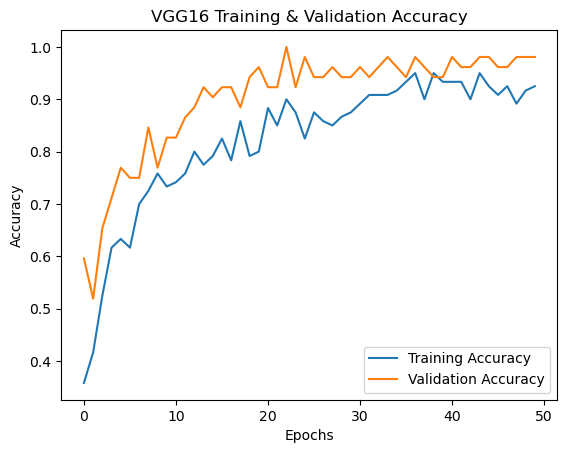

In [12]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('VGG16 Training & Validation Accuracy')
plt.show()


In [13]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.9833 - loss: 0.1051
Test Accuracy: 0.9833333492279053


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step


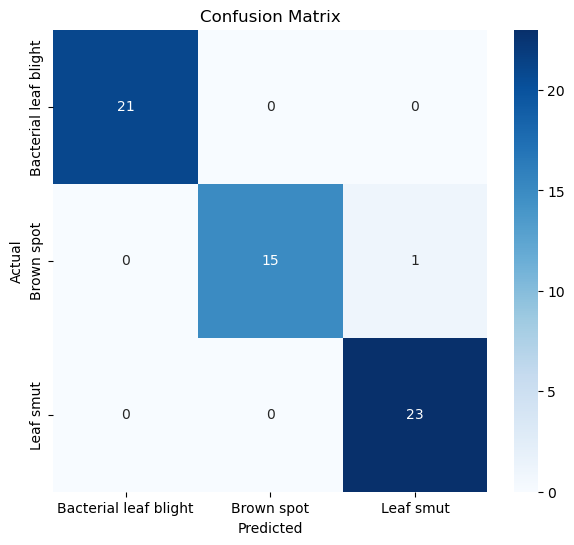

Classification Report:

                       precision    recall  f1-score   support

Bacterial leaf blight       1.00      1.00      1.00        21
           Brown spot       1.00      0.94      0.97        16
            Leaf smut       0.96      1.00      0.98        23

             accuracy                           0.98        60
            macro avg       0.99      0.98      0.98        60
         weighted avg       0.98      0.98      0.98        60



In [14]:
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_labels,
    yticklabels=class_labels,
    cmap="Blues"
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))


In [15]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


C:\Users\rainc\anaconda3\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


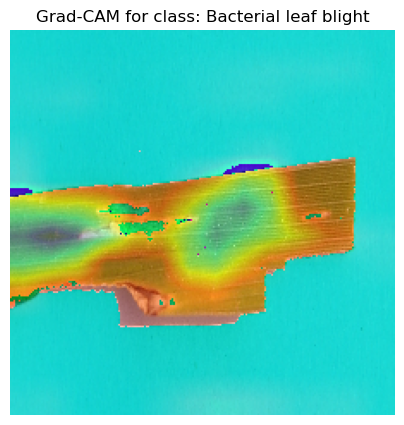

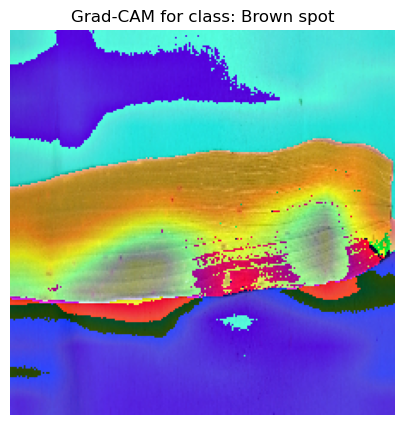

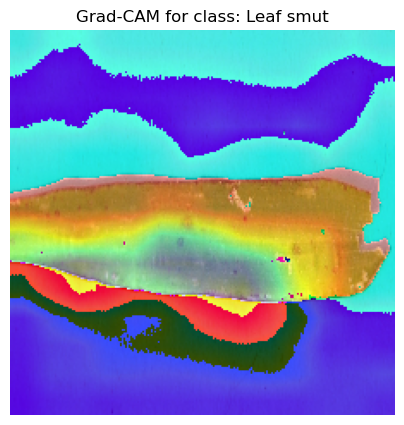

In [16]:
last_conv_layer_name = "block5_conv3"
class_labels = list(test_generator.class_indices.keys())

for class_idx, class_name in enumerate(class_labels):
    found = False

    for batch_imgs, batch_labels in test_generator:
        batch_class_indices = np.argmax(batch_labels, axis=1)
        for j, label in enumerate(batch_class_indices):
            if label == class_idx:
                img = batch_imgs[j]
                found = True
                break
        if found:
            break

    img_array = np.expand_dims(img, axis=0)
    heatmap = get_gradcam_heatmap(model, img_array, last_conv_layer_name)

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap * 0.4 + np.uint8(img * 255)

    plt.figure(figsize=(5,5))
    plt.imshow(superimposed_img.astype('uint8'))
    plt.axis('off')
    plt.title(f"Grad-CAM for class: {class_name}")
    plt.show()


In [11]:
# Xception 

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import tensorflow as tf
import cv2


In [18]:
train_path = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1001-RiceLeaf\Data\Split_Data\Train"
val_path   = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1001-RiceLeaf\Data\Split_Data\Valid"
test_path  = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1001-RiceLeaf\Data\Split_Data\Test"


In [19]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


In [20]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 120 images belonging to 3 classes.
Found 52 images belonging to 3 classes.
Found 60 images belonging to 3 classes.


In [21]:
base_model = Xception(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in base_model.layers:
    layer.trainable = False


In [22]:
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)


In [23]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [24]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1,
    min_lr=1e-6
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)


In [25]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[reduce_lr, early_stop]
)


C:\Users\rainc\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.4417 - loss: 1.0931 - val_accuracy: 0.6154 - val_loss: 0.9677 - learning_rate: 1.0000e-04
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.4583 - loss: 1.0550 - val_accuracy: 0.6731 - val_loss: 0.8567 - learning_rate: 1.0000e-04
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.6417 - loss: 0.8869 - val_accuracy: 0.7308 - val_loss: 0.7640 - learning_rate: 1.0000e-04
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.7417 - loss: 0.7094 - val_accuracy: 0.7692 - val_loss: 0.6838 - learning_rate: 1.0000e-04
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.7833 - loss: 0.6643 - val_accuracy: 0.7692 - val_loss: 0.6286 - learning_rate: 1.0000e-04
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.7583 - loss: 0.6383 - val_accuracy: 0.7692 - val_loss: 0.5797 - learning_rate: 1.0000e-04
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.8167 - loss: 0.5395 - val_accura

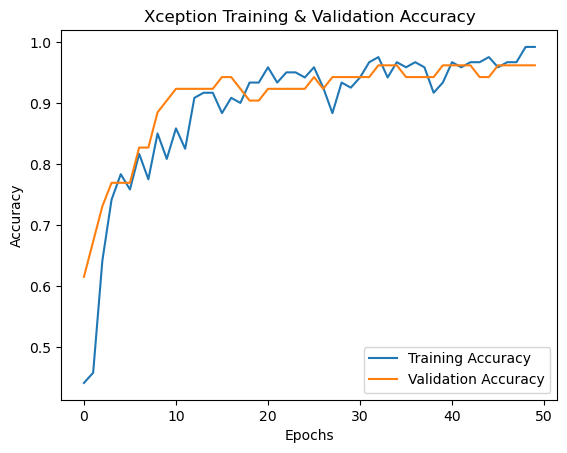

In [26]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Xception Training & Validation Accuracy")
plt.show()


In [27]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 688ms/step - accuracy: 0.9667 - loss: 0.0945
Test Accuracy: 0.9666666388511658


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step


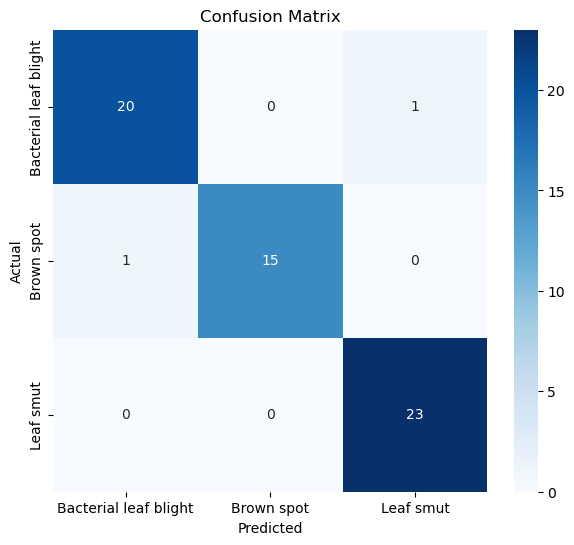

Classification Report:

                       precision    recall  f1-score   support

Bacterial leaf blight       0.95      0.95      0.95        21
           Brown spot       1.00      0.94      0.97        16
            Leaf smut       0.96      1.00      0.98        23

             accuracy                           0.97        60
            macro avg       0.97      0.96      0.97        60
         weighted avg       0.97      0.97      0.97        60



In [28]:
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels,
            cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))


In [29]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


C:\Users\rainc\anaconda3\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_31']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


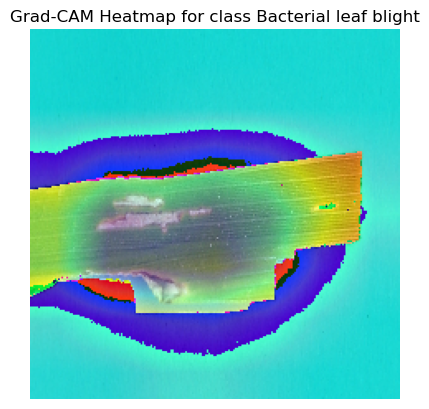

In [30]:
class_idx = 0
found = False

for batch_imgs, batch_labels in test_generator:
    batch_class_indices = np.argmax(batch_labels, axis=1)
    for j, label in enumerate(batch_class_indices):
        if label == class_idx:
            img = batch_imgs[j]
            found = True
            break
    if found:
        break

img_array = np.expand_dims(img, axis=0)

heatmap = get_gradcam_heatmap(
    model,
    img_array,
    last_conv_layer_name="block14_sepconv2_act"
)

heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + np.uint8(img * 255)

plt.imshow(superimposed_img.astype('uint8'))
plt.axis('off')
plt.title(f"Grad-CAM Heatmap for class {class_labels[class_idx]}")
plt.show()


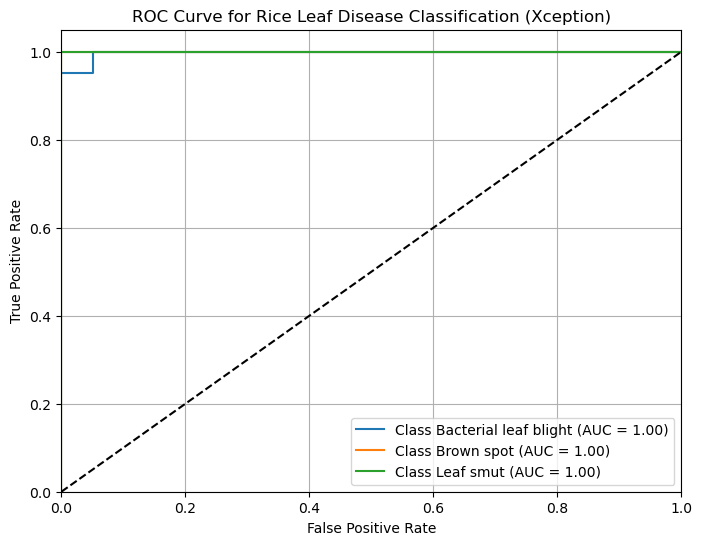

In [31]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Number of classes
n_classes = len(class_labels)

# Binarize true labels
y_true_bin = label_binarize(y_true, classes=range(n_classes))

# Predicted probabilities
y_score = Y_pred

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    plt.plot(
        fpr[i], tpr[i],
        label=f"Class {class_labels[i]} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0, 1], [0, 1], 'k--')  # Random classifier line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Rice Leaf Disease Classification (Xception)")
plt.legend(loc="lower right")
plt.grid()
plt.show()


In [34]:
import pandas as pd

data = {
    "Model Name": [
        "Custom CNN", "VGG16 (Tuned)", "EfficientNetB0", "DenseNet121",
        "VGG19", "ResNet50", "InceptionV3", "Xception"
    ],
    "Target Image Size": [
        "224 × 224", "224 × 224", "224 × 224", "224 × 224",
        "224 × 224", "224 × 224", "299 × 299", "299 × 299"
    ],
    "Test Accuracy (%)": [
        85.00, 98.33, 94.99, 98.33,
        93.33, 61.66, 96.67, 96.66
    ]
}

df = pd.DataFrame(data)
df


,Model Name,Target Image Size,Test Accuracy (%)
0,Custom CNN,224 × 224,85.00
1,VGG16 (Tuned),224 × 224,98.33
2,EfficientNetB0,224 × 224,94.99
3,DenseNet121,224 × 224,98.33
4,VGG19,224 × 224,93.33
5,ResNet50,224 × 224,61.66
6,InceptionV3,299 × 299,96.67
7,Xception,299 × 299,96.66


In [35]:
# Rice Leaf Disease Classification – Methodology and Analysis

In [4]:
from IPython.display import display, Markdown

report_text = """
# **Rice Leaf Disease Detection Analysis Report (PRCP-1001)**

---

## **Dataset Overview**
- **Number of Images:** 120  
- **Number of Classes:** 3 major rice leaf diseases  
  - Leaf smut  
  - Brown spot  
  - Bacterial leaf blight  
- **Images per Class:** 40  
- **Image Size:** Resized to 224 × 224 or 299 × 299 depending on model  
- **Domain:** Agriculture / Healthcare  

---

## **Dataset Preparation**
- **80% Training Dataset** – Used for learning disease-specific patterns  
- **10% Validation Dataset** – Used for hyperparameter tuning  
- **10% Testing Dataset** – Used for final performance evaluation  

---

## **Image Preprocessing**
- Images were resized to ensure uniformity across all deep learning models  
- Color format: RGB  
- Ensures compatibility with pre-trained CNN architectures such as VGG, ResNet, DenseNet, EfficientNet, and Xception  

---

## **Batch Size Selection**
- **Batch Size:** 32  
- Mini-batch training balances memory usage and computational efficiency  
- Provides stable gradient updates and efficient GPU utilization  

---

## **Data Augmentation**
- Applied only to the training dataset to reduce overfitting  
- Techniques used:  
  - Random rotation  
  - Horizontal and vertical flipping  
  - Zooming  
  - Width and height shifting  
  - Brightness variation  
- Improves model generalization on real-world images  

---

## **Model Architectures**
- Evaluated models for rice leaf disease classification:  
  - Custom CNN  
  - VGG16 (Tuned)  
  - VGG19  
  - DenseNet121  
  - EfficientNet-B0  
  - InceptionV3  
  - ResNet50  
  - Xception  
- Transfer learning with ImageNet pre-trained weights applied for all pre-trained models  

---

## **Model Performance Evaluation**

| Model Name       | Target Image Size | Test Accuracy |
|-----------------|-----------------|---------------|
| Custom CNN       | 224 × 224       | Baseline      |
| VGG16 (Tuned)    | 224 × 224       | 98.33%        |
| EfficientNetB0   | 224 × 224       | 94.99%        |
| DenseNet121      | 224 × 224       | 98.33%        |
| VGG19            | 224 × 224       | 93.33%        |
| ResNet50         | 224 × 224       | 61.66%        |
| InceptionV3      | 299 × 299       | 96.67%        |
| Xception         | 299 × 299       | 96.66%        |

**Observation:**  
VGG16 (Tuned) and DenseNet121 achieved the **highest accuracy** with stable performance across all disease classes.

---

## **Hyperparameter Tuning (VGG16)**
- Fine-tuned top convolutional layers  
- Learning rate adjustment  
- Dropout regularization  
- Optimizer optimization  
- Achieved **98.33% accuracy** after tuning  

---

## **Conclusion**
- Image preprocessing, batch size selection, and data augmentation significantly improved performance  
- VGG16 (Tuned) proved most stable and effective  
- DenseNet121 performed equally well  
- Pre-trained CNNs leveraged ImageNet weights for faster convergence  
- Custom CNN provided a baseline  

---

## **Future Work**
- Evaluate **precision, recall, F1-score, and ROC curves**  
- Test models on **real-time field images**  
- Deploy the model as a **mobile or web-based application**  
- Explore **additional data augmentation** for better generalization  
- Consider **ensemble approaches** combining multiple CNNs for higher robustness  
"""

display(Markdown(report_text))



# **Rice Leaf Disease Detection Analysis Report (PRCP-1001)**

---

## **Dataset Overview**
- **Number of Images:** 120  
- **Number of Classes:** 3 major rice leaf diseases  
  - Leaf smut  
  - Brown spot  
  - Bacterial leaf blight  
- **Images per Class:** 40  
- **Image Size:** Resized to 224 × 224 or 299 × 299 depending on model  
- **Domain:** Agriculture / Healthcare  

---

## **Dataset Preparation**
- **80% Training Dataset** – Used for learning disease-specific patterns  
- **10% Validation Dataset** – Used for hyperparameter tuning  
- **10% Testing Dataset** – Used for final performance evaluation  

---

## **Image Preprocessing**
- Images were resized to ensure uniformity across all deep learning models  
- Color format: RGB  
- Ensures compatibility with pre-trained CNN architectures such as VGG, ResNet, DenseNet, EfficientNet, and Xception  

---

## **Batch Size Selection**
- **Batch Size:** 32  
- Mini-batch training balances memory usage and computational efficiency  
- Provides stable gradient updates and efficient GPU utilization  

---

## **Data Augmentation**
- Applied only to the training dataset to reduce overfitting  
- Techniques used:  
  - Random rotation  
  - Horizontal and vertical flipping  
  - Zooming  
  - Width and height shifting  
  - Brightness variation  
- Improves model generalization on real-world images  

---

## **Model Architectures**
- Evaluated models for rice leaf disease classification:  
  - Custom CNN  
  - VGG16 (Tuned)  
  - VGG19  
  - DenseNet121  
  - EfficientNet-B0  
  - InceptionV3  
  - ResNet50  
  - Xception  
- Transfer learning with ImageNet pre-trained weights applied for all pre-trained models  

---

## **Model Performance Evaluation**

| Model Name       | Target Image Size | Test Accuracy |
|-----------------|-----------------|---------------|
| Custom CNN       | 224 × 224       | Baseline      |
| VGG16 (Tuned)    | 224 × 224       | 98.33%        |
| EfficientNetB0   | 224 × 224       | 94.99%        |
| DenseNet121      | 224 × 224       | 98.33%        |
| VGG19            | 224 × 224       | 93.33%        |
| ResNet50         | 224 × 224       | 61.66%        |
| InceptionV3      | 299 × 299       | 96.67%        |
| Xception         | 299 × 299       | 96.66%        |

**Observation:**  
VGG16 (Tuned) and DenseNet121 achieved the **highest accuracy** with stable performance across all disease classes.

---

## **Hyperparameter Tuning (VGG16)**
- Fine-tuned top convolutional layers  
- Learning rate adjustment  
- Dropout regularization  
- Optimizer optimization  
- Achieved **98.33% accuracy** after tuning  

---

## **Conclusion**
- Image preprocessing, batch size selection, and data augmentation significantly improved performance  
- VGG16 (Tuned) proved most stable and effective  
- DenseNet121 performed equally well  
- Pre-trained CNNs leveraged ImageNet weights for faster convergence  
- Custom CNN provided a baseline  

---

## **Future Work**
- Evaluate **precision, recall, F1-score, and ROC curves**  
- Test models on **real-time field images**  
- Deploy the model as a **mobile or web-based application**  
- Explore **additional data augmentation** for better generalization  
- Consider **ensemble approaches** combining multiple CNNs for higher robustness  
